# Numerical edge cases

The expansions divide by quantities that can vanish. This notebook walks the cases where a naive implementation returns NaN, and shows what this one returns instead — every one of them was a real defect fixed in the 1.1.0 audit, and every one has a regression test.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

## A Hamiltonian proportional to the identity

If $H \propto \mathbb{1}$ the traceless part vanishes, so $|h| = 0$ and the SU(3) expansion divides by zero. The correct answer is that nothing oscillates: $U = \mathbb{1}$.

In [2]:
H = np.eye(3, dtype=complex)*3.7
prob = np.array(oscprob3nu.probabilities_3nu(H, 5.0))
print("P = ", np.round(prob, 12))
print("no NaN:", not np.any(np.isnan(prob)))
print("identity:", np.allclose(prob.reshape(3, 3), np.eye(3)))

P =  [1. 0. 0. 0. 1. 0. 0. 0. 1.]
no NaN: True
identity: True


## A doubly degenerate spectrum

`diag(1, 1, -2)` has two equal latent roots. The Lagrange interpolation used for the coefficients divides by $3\psi_m^2 - |h|^2$, which vanishes exactly at a repeated root; the confluent limit is taken instead.

In [3]:
from scipy.linalg import expm

H = np.diag([1.0, 1.0, -2.0]).astype(complex)
L = 0.9

U = np.array(oscprob3nu.evolution_operator_3nu(H, L))
U_ref = expm(-1.0j*(H - np.trace(H)/3.0*np.eye(3))*L)

print("max |U - expm| = %.2e" % np.max(np.abs(U-U_ref)))
print("unitary to     = %.2e"
      % np.max(np.abs(U.conj().T @ U - np.eye(3))))

max |U - expm| = 5.12e-16
unitary to     = 6.66e-16


## Approaching degeneracy

The dangerous region is not the degenerate point itself but its neighbourhood, where the denominator is small but not zero. Sweeping a splitting down to $10^{-15}$ against an independent matrix exponential shows what actually happens: the result stays finite and unitary throughout, but accuracy is *not* round-off across the whole range. In the crossover band, where the denominator is small but the degenerate branch has not yet been taken, the error peaks around $10^{-8}$ before dropping back. That is worth knowing and is reported below rather than glossed.

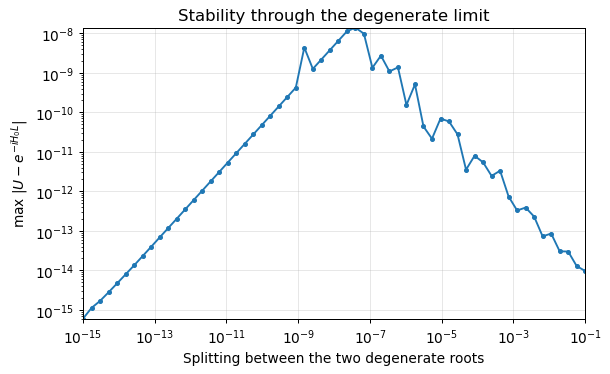

worst error across the sweep : 1.40e-08
error at the tightest splitting: 5.98e-16
worst at a splitting of        : 3.9e-08


In [4]:
errors, splittings = [], np.logspace(-1.0, -15.0, 60)
for eps in splittings:
    H = np.diag([1.0, 1.0+eps, -2.0-eps]).astype(complex)
    U = np.array(oscprob3nu.evolution_operator_3nu(H, 0.9))
    U_ref = expm(-1.0j*(H-np.trace(H)/3.0*np.eye(3))*0.9)
    errors.append(np.max(np.abs(U-U_ref)))

fig, ax = plt.subplots()
ax.loglog(splittings, errors, "o-", ms=3)
ax.set_xlim(splittings[-1], splittings[0])
ax.set_xlabel("Splitting between the two degenerate roots")
ax.set_ylabel(r"max $|U - e^{-iH_0L}|$")
ax.set_title("Stability through the degenerate limit")
plt.show()

print("worst error across the sweep : %.2e" % max(errors))
print("error at the tightest splitting: %.2e" % errors[-1])
worst = splittings[int(np.argmax(errors))]
print("worst at a splitting of        : %.1e" % worst)

## Two flavors: the same limit

The SU(2) expansion carries $\sin(|h|L)/|h|$, which needs its limit $\to L$ at $|h| = 0$.

In [5]:
H2 = np.eye(2, dtype=complex)*2.5
p = np.array(oscprob2nu.probabilities_2nu(H2, 3.0))
print("P =", np.round(p, 12))
print("no NaN:", not np.any(np.isnan(p)))

P = [1. 0. 0. 1.]
no NaN: True


## Index validation

`tensor_d` used to fall off the end of an `elif` chain and return `None` for an out-of-range index, so the failure surfaced far from its cause as a `TypeError` in whatever consumed it. It now raises `IndexError` at the point of the mistake.

In [6]:
print("d_007 = %.6f" % oscprob3nu.tensor_d(0, 0, 7))
try:
    oscprob3nu.tensor_d(0, 1, 99)
except IndexError as error:
    print("out of range ->", type(error).__name__, error)

d_007 = 0.577350
out of range -> IndexError tensor_d: index 99 is outside the range 0-7


## Very long and very short baselines

Nothing special happens at either extreme, but it is worth confirming: at $L = 0$ the operator is the identity, and at very large $HL$ the probabilities stay bounded and normalised rather than accumulating round-off.

In [7]:
rng = np.random.default_rng(1)
a = rng.normal(size=(3, 3)) + 1.0j*rng.normal(size=(3, 3))
H = (a + a.conj().T)/2.0

U0 = np.array(oscprob3nu.evolution_operator_3nu(H, 0.0))
print("U(0) = identity:", np.allclose(U0, np.eye(3)))

for L in (1.0e3, 1.0e6, 1.0e9):
    p = np.array(oscprob3nu.probabilities_3nu(H, L))
    print("L = %.0e : sum over final flavors = %.12f, "
          "min = %.2e" % (L, p[:3].sum(), p.min()))

U(0) = identity: True
L = 1e+03 : sum over final flavors = 1.000000000000, min = 7.15e-02
L = 1e+06 : sum over final flavors = 1.000000000000, min = 1.34e-01
L = 1e+09 : sum over final flavors = 1.000000000000, min = 5.03e-02


Every case above is covered by `tests/test_edge_cases.py`, which is what keeps them from regressing. They are collected here because a user meeting a NaN wants to know whether it is their Hamiltonian or the library — and the answer, for all of these, is that it is neither.

---

**Previous:** [Solar neutrinos and the MSW resonance](14_solar_and_adiabatic_msw.ipynb)  
**Next:** [Four neutrinos, and a sterile state](16_four_neutrinos.ipynb) --- a 3+1 system through SU(4), and why the method stops there  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)